In [1]:
# reload modules before execution (for the changing code in src)
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import sys

sys.path.append(str(Path.cwd().parent))
import src.utils as utils

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [3]:
findex_db_name = '../data/raw/Findex.db'
sql_folder = '../sql/'

pic_folder = '../articles/unit_measure/pic/'

In [4]:
def plot_buckets_countries(no_buckets, 
                           data, 
                           value_col_name, 
                           palette,
                          title: str | None = "",
                          save_file: str | None = ""
):
    '''
    series is assumed to have percentages,
    series values is for (country)
    buckets are uniform within 0-100 range
    '''
    plot_data = data.copy()
    
    # plotting percentages
    min_range = 0
    max_range = 100
    # assign a bucket, range divided uniformly
    plot_data['clusters'], edges = utils.divide_range_into_buckets(no_buckets, min_range, max_range, data[value_col_name])

    # recover categories
    categories = np.sort(plot_data['clusters'].dropna().astype(int).unique())

    # prepare labels
    labels = utils.prepare_labels(edges, categories)
    
    plot_palette = dict(zip(categories, palette))

    plot_data.set_index('country_id', drop = True, inplace = True)
    
    utils.plot_cluster_map(plot_data['clusters'], 
        labels = labels, 
        palette = plot_palette,
        title = title,
        save_file_name = save_file
    )

In [5]:
spreads_tuples = utils.run_sql(findex_db_name, sql_folder + 'spreads.sql')
spreads = pd.DataFrame(spreads_tuples, columns = ['unit_measure', 'unit_measure_label', 'country_id', 'country_name', 'observation_date', 'min_derived', 'max_derived', 'spread'])

In [6]:
# extract maximum spread for each unit_measure value
max_spreads = spreads.groupby(['unit_measure', 'unit_measure_label'], as_index = False)['spread'].max().sort_values(by = ['spread'])
max_spreads['spread'] = max_spreads['spread'].round(4)

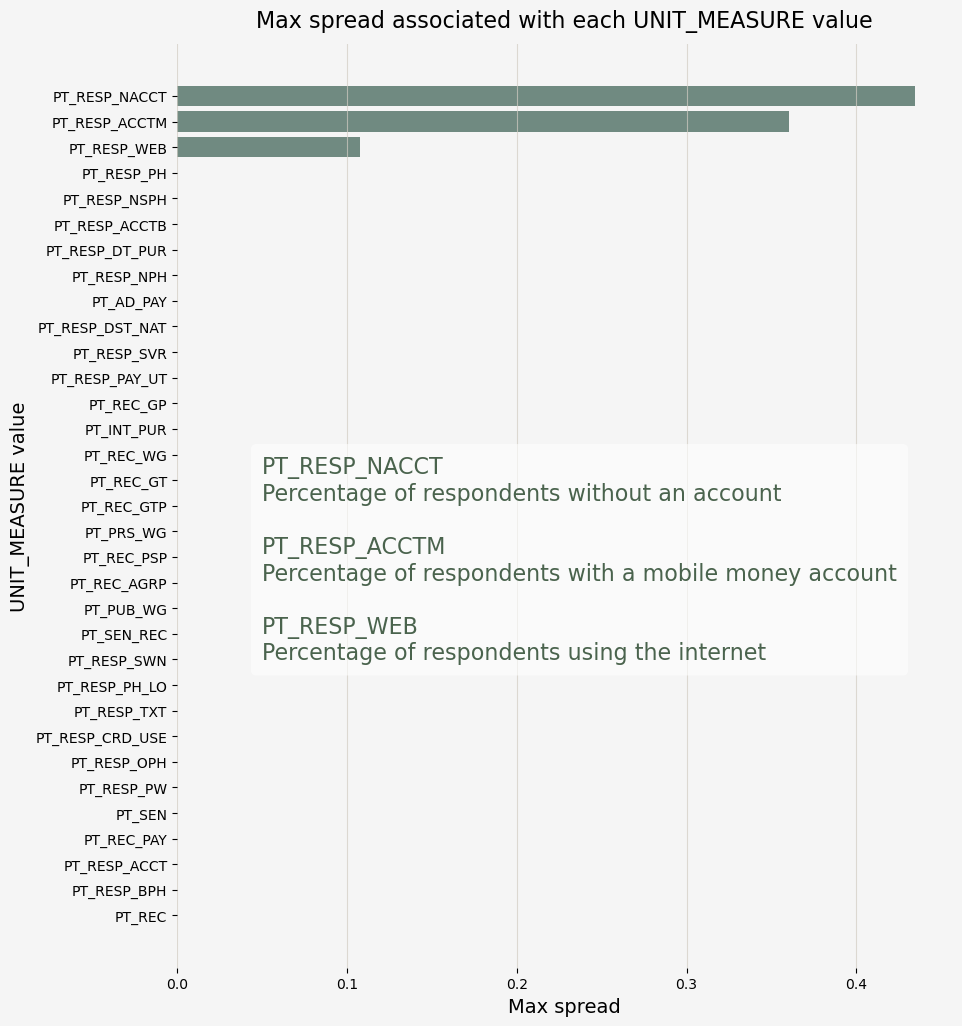

In [7]:
annotation_data = (max_spreads[max_spreads['spread'] > 0]
    .sort_values(by = ['spread'], ascending = False)[['unit_measure', 'unit_measure_label']]
    .values)

annotation_text = '\n\n'.join(
    f'{unit_measure}\n{label}'
    for unit_measure, label in annotation_data
)

utils.pretty_hbar(max_spreads['unit_measure'], max_spreads['spread'],
           plot_title = "Max spread associated with each UNIT_MEASURE value",
           x_axis_title = "Max spread",
           y_axis_title = "UNIT_MEASURE value",
           annotation={
                    "bbox": {
                            "boxstyle": "round,pad=0.5,rounding_size=0.25",
                            "fc": "white",          # fill color
                            "ec": "none",
                            #"ec": "#a5c4b6",
                            #"lw": 1,
                            "alpha": 0.6
                    },
                    "text": annotation_text,
                    "xy": (0, 32),
                    "xytext": (0.05, 10),
                    "color": "#4a634d",
                    "fontsize": 16
                },
           save_file = pic_folder + 'spreads_hbar.png')

In [8]:
# UNIT_MEASURE values with non-zero spreads
um_non_zero = spreads.loc[spreads['spread'] > 10e-9, 'unit_measure'].unique()

In [9]:
non_zero_spreads = spreads[spreads['unit_measure'].isin(um_non_zero)].copy()
non_zero_spreads.reset_index(drop = True, inplace = True)

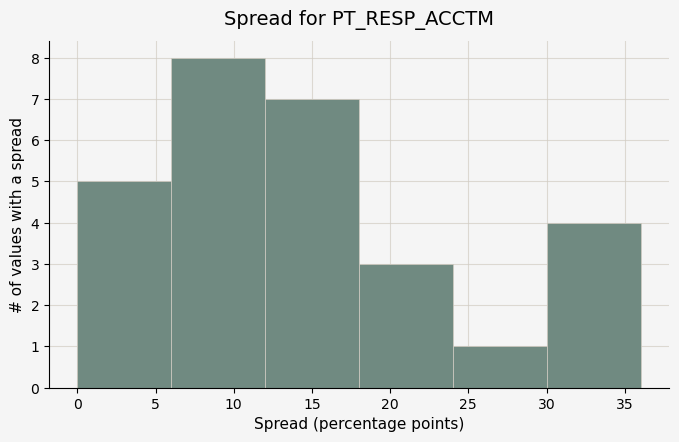

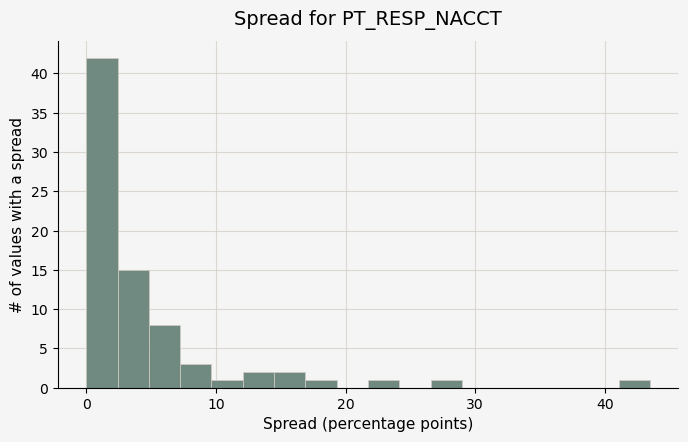

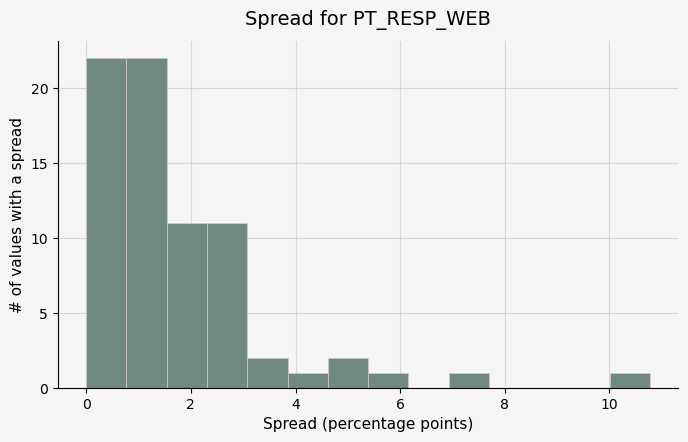

In [10]:
for val in um_non_zero:
    utils.pretty_histogram(non_zero_spreads.loc[non_zero_spreads['unit_measure'] == val, 'spread'] * 100, 
                           title = 'Spread for ' + val,
                           x_axis_title = 'Spread (percentage points)',
                           y_axis_title = '# of values with a spread',
                          save_file_name = pic_folder + val + '_spread.png')

In [11]:
um_indicators_tuples = utils.run_sql(findex_db_name, sql_folder + 'unit_measure_indicators.sql')
um_indicators = pd.DataFrame(um_indicators_tuples, columns = ['unit_measure', 'unit_measure_label', 'indicator', 'indicator_label', 'no_observations'])

assert (um_indicators['unit_measure'].unique() == um_non_zero).all()

In [12]:
# data range check
paired_tuples = utils.run_sql(findex_db_name, sql_folder + 'data_paired.sql')
paired_data = pd.DataFrame(paired_tuples,
                                               columns = ['um', 'country_id', 'observation_date', 'indicator', 'cond_val', 'base_val', 'der_val'])

assert len(paired_data) == um_indicators['no_observations'].sum()

print((paired_data[['cond_val', 'base_val', 'der_val']] > 0).sum())
print((paired_data[['cond_val', 'base_val', 'der_val']] < 1).sum())
print((paired_data[['cond_val', 'base_val', 'der_val']] < 100).sum())

cond_val    1201
base_val    1201
der_val     1201
dtype: int64
cond_val       0
base_val       0
der_val     1201
dtype: int64
cond_val    1201
base_val    1201
der_val     1201
dtype: int64


# PT_RESP_ACCTM Percentage of respondents with a mobile money account

In [13]:
mobile_money_acc_mask = um_indicators['unit_measure'] == 'PT_RESP_ACCTM'

In [14]:
um_indicators[mobile_money_acc_mask]

,unit_measure,unit_measure_label,indicator,indicator_label,no_observations
0,PT_RESP_ACCTM,Percentage of respondents with a mobile money ...,WB_FINDEX_FIN13ALM,"Deposited money into a mobile money account, l...",24
1,PT_RESP_ACCTM,Percentage of respondents with a mobile money ...,WB_FINDEX_FIN13AM,"Deposited money into a mobile money account, m...",24
2,PT_RESP_ACCTM,Percentage of respondents with a mobile money ...,WB_FINDEX_FIN13AW,"Deposited money into a mobile money account, w...",10
3,PT_RESP_ACCTM,Percentage of respondents with a mobile money ...,WB_FINDEX_FIN13BLM,"Sent money from a mobile money account, less t...",24
4,PT_RESP_ACCTM,Percentage of respondents with a mobile money ...,WB_FINDEX_FIN13BM,"Sent money from a mobile money account, monthly",22
5,PT_RESP_ACCTM,Percentage of respondents with a mobile money ...,WB_FINDEX_FIN13BW,"Sent money from a mobile money account, weekly",9
6,PT_RESP_ACCTM,Percentage of respondents with a mobile money ...,WB_FINDEX_FIN13CLM,"Took out money from a mobile money account, le...",23
7,PT_RESP_ACCTM,Percentage of respondents with a mobile money ...,WB_FINDEX_FIN13CM,"Took out money from a mobile money account, mo...",22
8,PT_RESP_ACCTM,Percentage of respondents with a mobile money ...,WB_FINDEX_FIN13CW,"Took out money from a mobile money account, we...",12
9,PT_RESP_ACCTM,Percentage of respondents with a mobile money ...,WB_FINDEX_FIN13F,Sent money to the wrong number,14


4 groups of indicators emerge:
- fin13a,
- fin13b,
- fin13c,
- other

In [15]:
# fin13a, fin13c and fin13f together have 0 spread

mobile_money_acc_zero_spreads_tuples = utils.run_sql(findex_db_name, sql_folder + 'mobile_money_acc_zero_spread.sql')
mobile_money_acc_zero_spreads = pd.DataFrame(mobile_money_acc_zero_spreads_tuples, 
                                             columns = ['um', 'um_label', 'country_id', 'country_name', 'observation_date', 'min_derived', 'max_derived', 'spread'])

In [16]:
# fin13a, fin13c and fin13f together have 0 spread
# adding fin13b gived max spread of about 1.4%

mobile_money_acc_small_spreads_tuples = utils.run_sql(findex_db_name, sql_folder + 'mobile_money_acc_small_spread.sql')
mobile_money_acc_small_spreads = pd.DataFrame(mobile_money_acc_small_spreads_tuples, 
                                             columns = ['um', 'um_label', 'country_id', 'country_name', 'observation_date', 'min_derived', 'max_derived', 'spread'])

fin13_1a_paired_tuples = utils.run_sql(findex_db_name, sql_folder + 'fin13_1a_paired.sql')
fin13_1a_paired = pd.DataFrame(fin13_1a_paired_tuples, columns = ['um', 'country_id', 'observation_date', 'indicator', 'cond_val', 'base_val', 'der_val'])

fin13_1b_paired_tuples = utils.run_sql(findex_db_name, sql_folder + 'fin13_1b_paired.sql')
fin13_1b_paired = pd.DataFrame(fin13_1b_paired_tuples, columns = ['um', 'country_id', 'observation_date', 'indicator', 'cond_val', 'base_val', 'der_val'])

In [17]:
mobile_money_acc = mobile_money_acc_small_spreads[['country_id', 'min_derived']].copy()
mobile_money_acc.rename(columns = {'min_derived': 'small_spread_der'}, inplace = True)

mobile_money_acc = pd.merge(fin13_1a_paired[['country_id', 'der_val']], mobile_money_acc, on = 'country_id', how = 'outer')
mobile_money_acc.rename(columns = {'der_val': 'fin13_1a_der'}, inplace = True)

mobile_money_acc = pd.merge(fin13_1b_paired[['country_id', 'der_val']], mobile_money_acc, on = 'country_id', how = 'outer')
mobile_money_acc.rename(columns = {'der_val': 'fin13_1b_der'}, inplace = True)

mobile_money_acc['min_der'] = mobile_money_acc[['fin13_1b_der', 'fin13_1a_der', 'small_spread_der']].min(axis = 1)
mobile_money_acc['max_der'] = mobile_money_acc[['fin13_1b_der', 'fin13_1a_der', 'small_spread_der']].max(axis = 1)

mobile_money_acc['spread'] = mobile_money_acc['max_der'] - mobile_money_acc['min_der']

mobile_money_acc.sort_values(by = 'spread', inplace = True)

In [18]:
ken_pop = 53330978
ken_row = mobile_money_acc[mobile_money_acc['country_id'] == 'KEN']
mob_acc_ken_pop_min = ken_row['min_der'] * ken_pop
mob_acc_ken_pop_max = ken_row['max_der'] * ken_pop

gha_pop = 35039451
gha_row = mobile_money_acc[mobile_money_acc['country_id'] == 'GHA']
mob_acc_gha_pop_min = gha_row['min_der'] * gha_pop
mob_acc_gha_pop_max = gha_row['max_der'] * gha_pop

sen_pop = 18847519
sen_row = mobile_money_acc[mobile_money_acc['country_id'] == 'SEN']
mob_acc_sen_pop_min = sen_row['min_der'] * sen_pop
mob_acc_sen_pop_max = sen_row['max_der'] * sen_pop

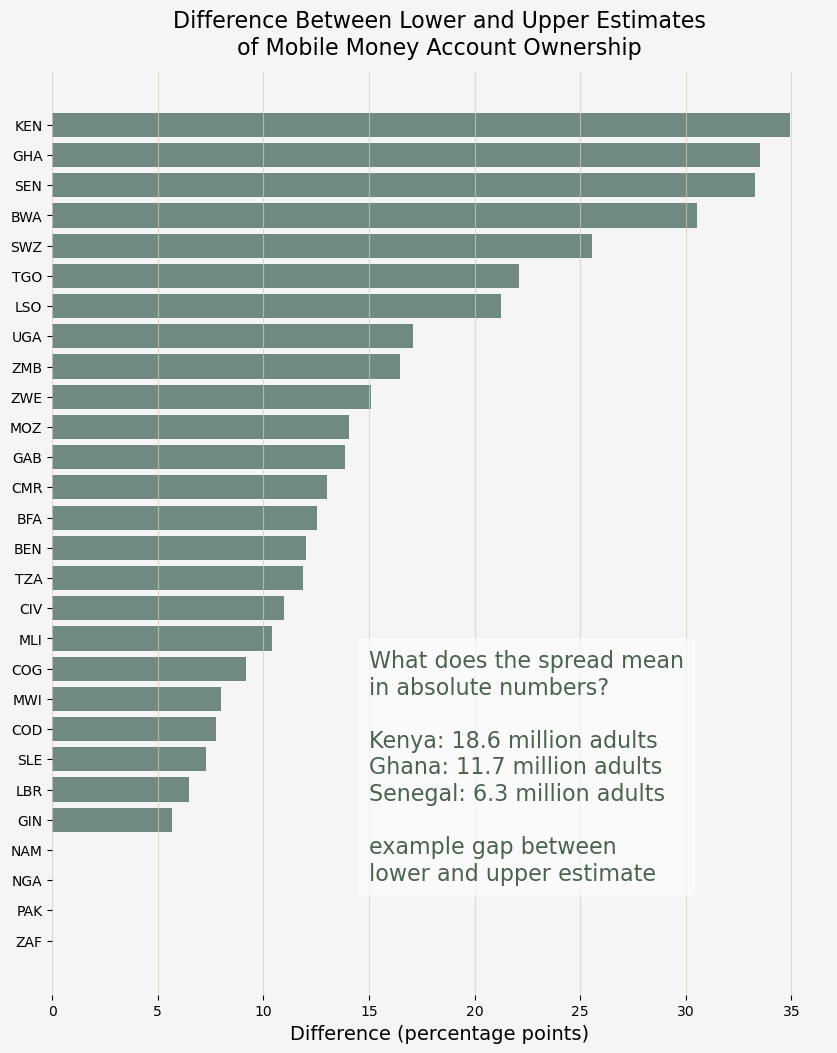

In [19]:
annotation_text = (
    "% (min, max) with a mobile money account in:\n"
    f"Kenya: {mob_acc_ken_pop_min.item() / 10e5:,.1f} and {mob_acc_ken_pop_max.item() / 10e5:,.1f}\n"
    f"Ghana: {mob_acc_gha_pop_min.item() / 10e5:,.1f} and {mob_acc_gha_pop_max.item() / 10e5:,.1f}\n"
    f"Senegal: {mob_acc_sen_pop_min.item() / 10e5:,.1f} and {mob_acc_sen_pop_max.item() / 10e5:,.1f}\n"
    "million people"
)
annotation_text = (
    "What does the spread mean\nin absolute numbers?\n\n"
    f"Kenya: {(mob_acc_ken_pop_max.item() -  mob_acc_ken_pop_min.item())/ 10e5:,.1f} million adults\n"
    f"Ghana: {(mob_acc_gha_pop_max.item() - mob_acc_gha_pop_min.item()) / 10e5:,.1f} million adults\n"
    f"Senegal: {(mob_acc_sen_pop_max.item() - mob_acc_sen_pop_min.item()) / 10e5:,.1f} million adults\n\n"
    "example gap between\nlower and upper estimate"
)

utils.pretty_hbar(mobile_money_acc['country_id'], mobile_money_acc['spread'] * 100,
                plot_title = "Difference Between Lower and Upper Estimates\nof Mobile Money Account Ownership",
                x_axis_title = "Difference (percentage points)",
                annotation = {
                    "bbox": {
                            "boxstyle": "round,pad=0.5,rounding_size=0.25",
                            "fc": "white",          # fill color
                            "ec": "none",
                            #"ec": "#a5c4b6",
                            #"lw": 1,
                            "alpha": 0.6
                    },
                    "text": annotation_text,
                    "xy": (0, 0),
                    "xytext": (15, 2),
                    "color": "#4a634d",
                    "fontsize": 16
                },
                save_file = pic_folder + "mobile_acc_spread_hbar.png"
)

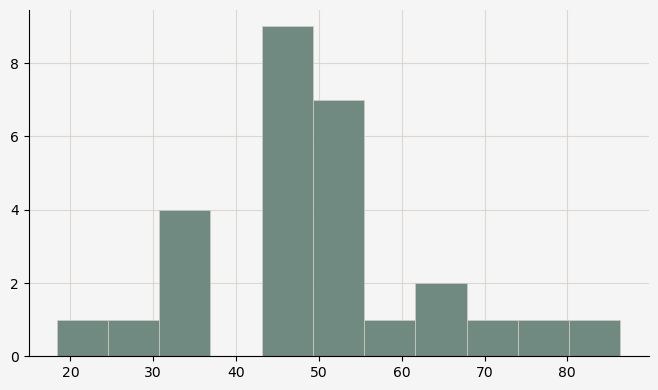

In [20]:
utils.pretty_histogram(mobile_money_acc_small_spreads['min_derived'] * 100)

## Countries where the World Bank reports stable estimates for selected behaviors among mobile money account holders.

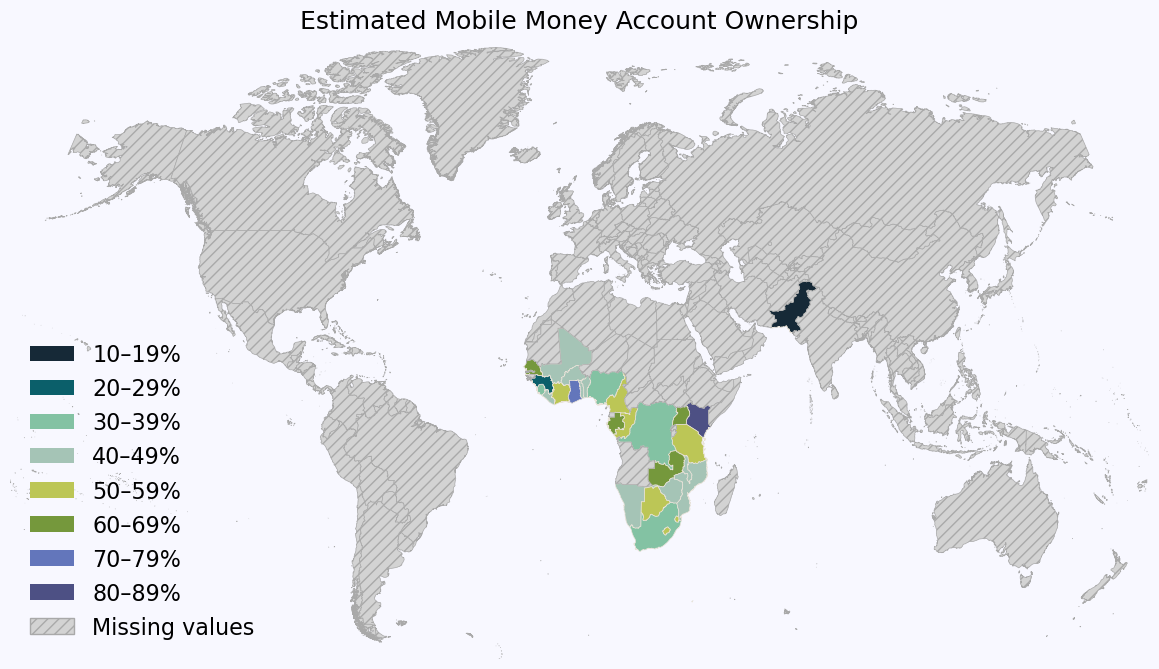

In [21]:
palette = [
    '#bcc656',
    '#75983c',
    '#6376bb',
    '#75518A',
    '#473356'
]
palette = [
    '#162937',
    '#0b5f6a',
    #'#44a288',
    '#83c2a3',
    '#a5c4b6',
    '#bcc656',
    '#75983c',
    '#6376bb',
    '#4d5084',
    '#141b8f',
    '#75518A',
    '#473356'
]

plot_data = mobile_money_acc_small_spreads[['country_id', 'min_derived']].copy()
plot_data['min_derived'] = plot_data['min_derived'] * 100

plot_buckets_countries(10, 
                       plot_data, 
                       'min_derived', 
                       palette,
                      title = "Estimated Mobile Money Account Ownership",
                      save_file = pic_folder + "mob_acc.png")

# PT_RESP_NACCT Percentage of respondents without an account

In [22]:
no_acc_mask = um_indicators['unit_measure'] == 'PT_RESP_NACCT'

In [23]:
um_indicators[no_acc_mask]

,unit_measure,unit_measure_label,indicator,indicator_label,no_observations
12,PT_RESP_NACCT,Percentage of respondents without an account,WB_FINDEX_FIN11A,No account because bank or similar financial i...,24
13,PT_RESP_NACCT,Percentage of respondents without an account,WB_FINDEX_FIN11B,No account because financial services are too ...,30
14,PT_RESP_NACCT,Percentage of respondents without an account,WB_FINDEX_FIN11C,No account because of a lack of necessary docu...,22
15,PT_RESP_NACCT,Percentage of respondents without an account,WB_FINDEX_FIN11D,No account because of insufficient funds,36
16,PT_RESP_NACCT,Percentage of respondents without an account,WB_FINDEX_FIN11E,No account because someone in the family has one,47
17,PT_RESP_NACCT,Percentage of respondents without an account,WB_FINDEX_FIN11F,No account because of a lack of trust in bank ...,24
18,PT_RESP_NACCT,Percentage of respondents without an account,WB_FINDEX_FIN11_1,Ever had an account at a bank or similar bank ...,9
19,PT_RESP_NACCT,Percentage of respondents without an account,WB_FINDEX_FIN11_2A,Can use account at a bank or similar financial...,37
20,PT_RESP_NACCT,Percentage of respondents without an account,WB_FINDEX_FIN14A,Reason for not having a mobile money account: ...,19
21,PT_RESP_NACCT,Percentage of respondents without an account,WB_FINDEX_FIN14B,Reason for not having a mobile money account: ...,18


fin11 group has up to 21% spread

In [24]:
fin11_paired_tuples = utils.run_sql(findex_db_name, sql_folder + 'fin11_paired_data.sql')
fin11_paired_data = pd.DataFrame(fin11_paired_tuples, columns = ['um', 'country_id', 'observation_date', 'indicator', 'cond_val', 'base_val', 'der_val'])

fin11_mask = um_indicators['indicator'].str.contains('FIN11[ABCDEF]')
assert len(fin11_paired_data) == um_indicators.loc[fin11_mask, 'no_observations'].sum()

In [25]:
fin11_spreads = fin11_paired_data.pivot(index = 'country_id', columns = 'indicator', values = 'der_val')
fin11_spreads.columns.name = None

fin11_spreads['min_der'] = fin11_spreads.min(axis = 1)
fin11_spreads['max_der'] = fin11_spreads.max(axis = 1)
fin11_spreads['spread'] = (fin11_spreads['max_der'] - fin11_spreads['min_der']).round(4)

fin11_spreads.sort_values(by = 'spread', inplace = True)

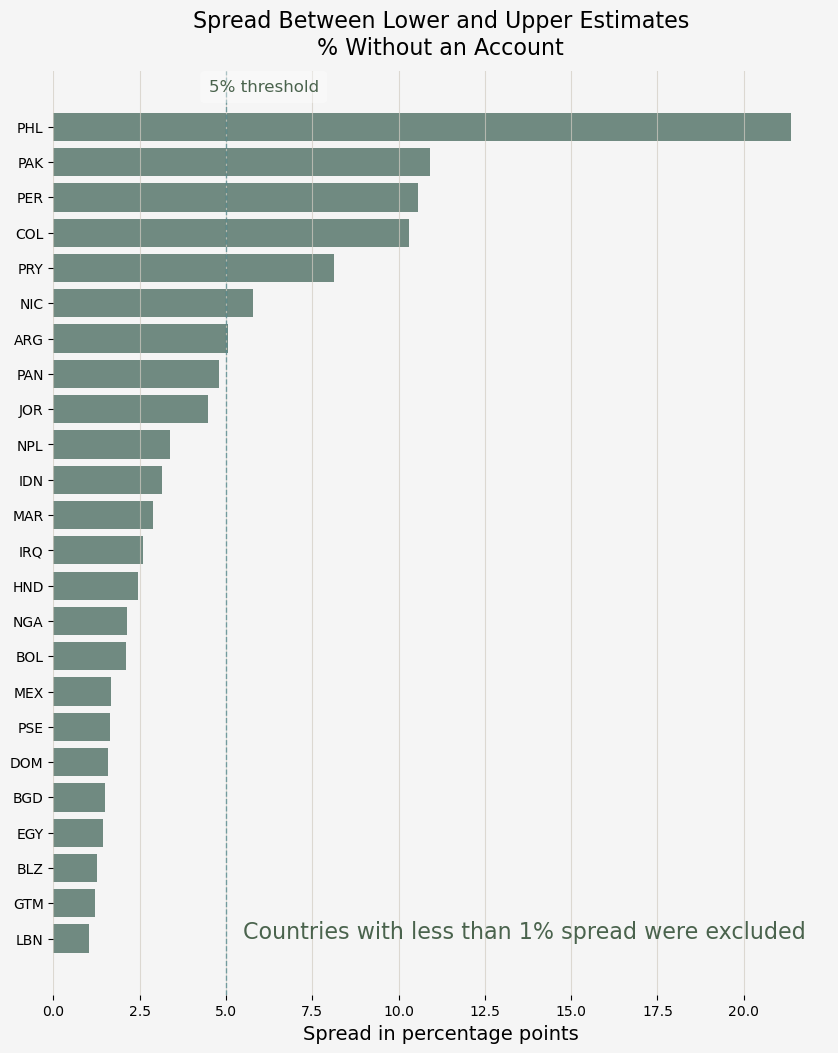

In [26]:
dashed_5p_annotation = "5% threshold"
expl_annotation = (
    "Countries with less than 1% spread were excluded"
)

plot_data = fin11_spreads[fin11_spreads['spread'] > 0.01]

utils.pretty_hbar(plot_data.index, plot_data['spread'] * 100,
                 vertical_lines = [5],
                 plot_title = "Spread Between Lower and Upper Estimates\n% Without an Account",
                  x_axis_title="Spread in percentage points",
                 annotation = [
                {"bbox": {
                            "boxstyle": "round,pad=0.5,rounding_size=0.25",
                            "fc": "white",          # fill color
                            "ec": "none",
                            #"ec": "#a5c4b6",
                            #"lw": 1,
                            "alpha": 0.4
                    },
                    "text": dashed_5p_annotation,
                    "xy": (0,0),
                    "xytext": (4.5, 24),
                    "color": "#4a634d",
                    "fontsize": 12
                },
                {"bbox": None,
                    "text": expl_annotation,
                    "xy": (0,0),
                    "xytext": (5.5, 0),
                    "color": "#4a634d",
                    "fontsize": 16
                }
                ],
        save_file = pic_folder + 'fin11_spreads.png'
)

In [27]:
print(fin11_spreads['min_der'].mean())
print(fin11_spreads['min_der'].std())

print(fin11_spreads['max_der'].mean())
print(fin11_spreads['max_der'].std())

0.4501881537743212
0.17516757705717587
0.47484938806897
0.1947407105546696


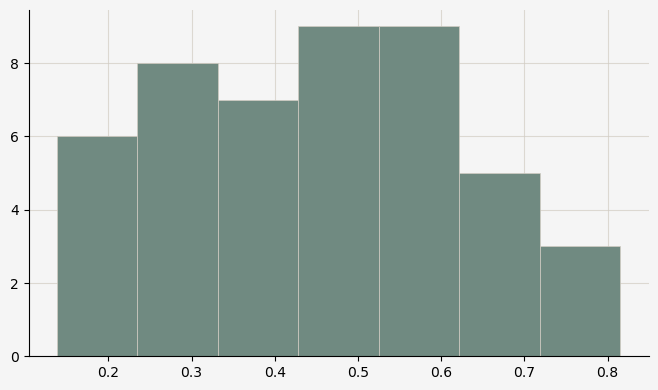

In [28]:
utils.pretty_histogram(fin11_spreads['min_der'])

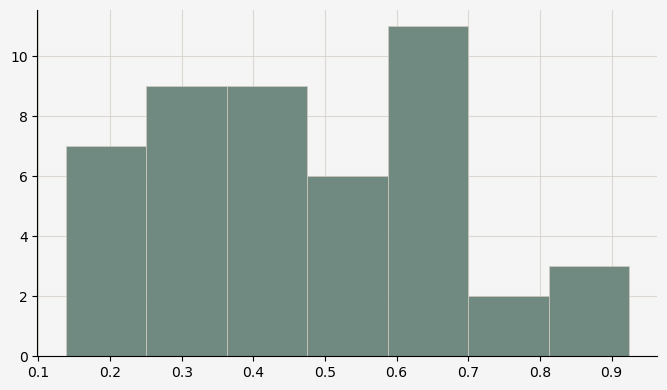

In [29]:
utils.pretty_histogram(fin11_spreads['max_der'])

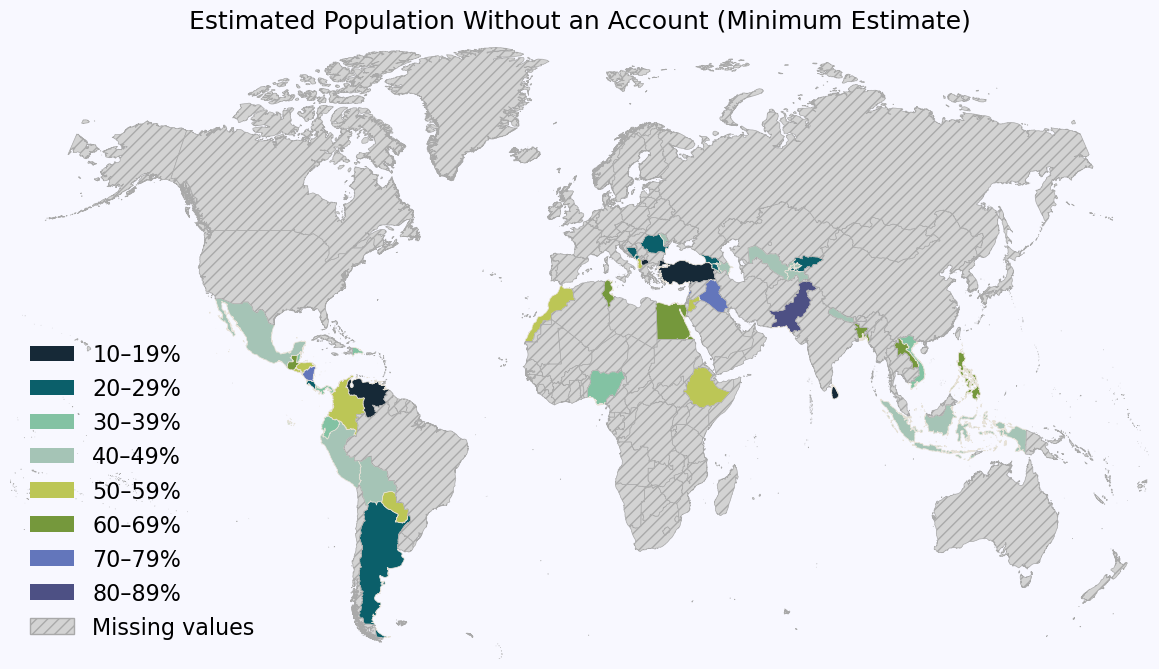

In [30]:
plot_data = fin11_spreads.reset_index()
plot_data[['country_id', 'min_der']].copy()
plot_data['min_der'] = plot_data['min_der'] * 100

plot_buckets_countries(10, 
                       plot_data, 
                       'min_der', 
                       palette,
                      title = "Estimated Population Without an Account (Minimum Estimate)",
                      save_file = pic_folder + "no_acc_min.png")

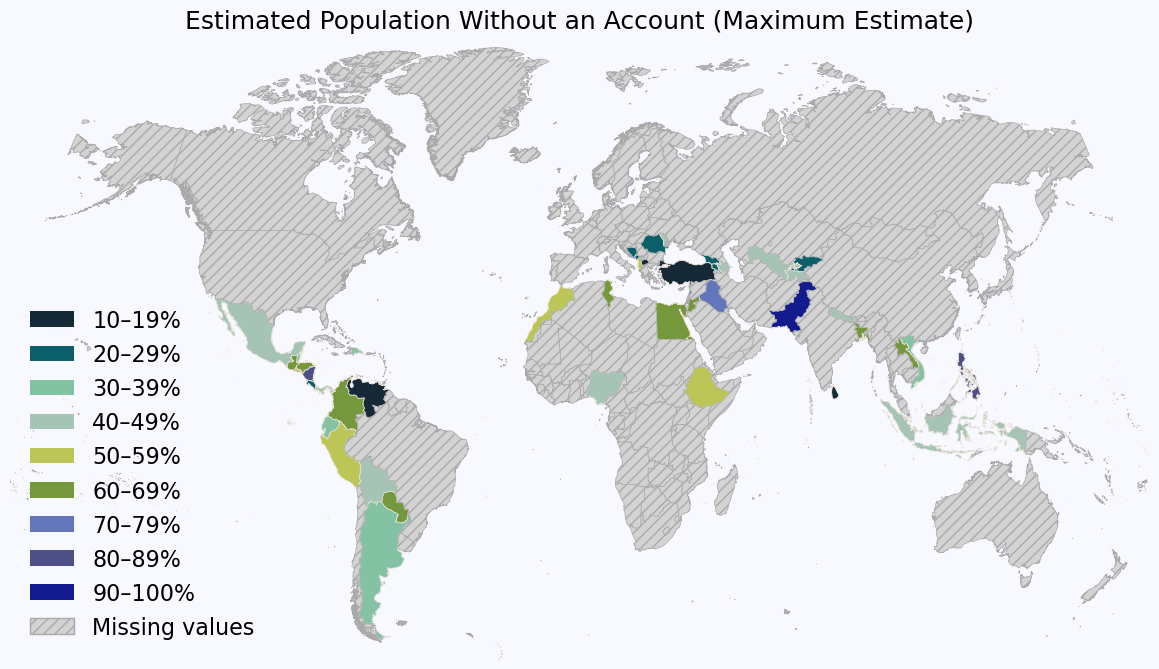

In [31]:
plot_data = fin11_spreads.reset_index()
plot_data[['country_id', 'max_der']].copy()
plot_data['max_der'] = plot_data['max_der'] * 100

plot_buckets_countries(10, 
                       plot_data, 
                       'max_der', 
                       palette,
                      title = "Estimated Population Without an Account (Maximum Estimate)",
                      save_file = pic_folder + "no_acc_max.png")

#  PT_RESP_WEB Percentage of respondents using the internet

In [32]:
internet_mask = um_indicators['unit_measure'] == 'PT_RESP_WEB'

In [33]:
um_indicators[internet_mask]

,unit_measure,unit_measure_label,indicator,indicator_label,no_observations
24,PT_RESP_WEB,Percentage of respondents using the internet,WB_FINDEX_CON26D,Daily internet use,67
25,PT_RESP_WEB,Percentage of respondents using the internet,WB_FINDEX_CON26LM,Less than once a month internet use,2
26,PT_RESP_WEB,Percentage of respondents using the internet,WB_FINDEX_CON26M,Monthly internet use,1
27,PT_RESP_WEB,Percentage of respondents using the internet,WB_FINDEX_CON26W,Weekly internet use,27
28,PT_RESP_WEB,Percentage of respondents using the internet,WB_FINDEX_CON27,Buys data package for internet use,73
29,PT_RESP_WEB,Percentage of respondents using the internet,WB_FINDEX_CON29,Connects to Internet only through free WiFi,17
30,PT_RESP_WEB,Percentage of respondents using the internet,WB_FINDEX_CON30A,Sent a voice message in past three months,71
31,PT_RESP_WEB,Percentage of respondents using the internet,WB_FINDEX_CON30B,Sent a photo in past three months,71
32,PT_RESP_WEB,Percentage of respondents using the internet,WB_FINDEX_CON30C,Used social media in past three months,74
33,PT_RESP_WEB,Percentage of respondents using the internet,WB_FINDEX_CON30D,Read news online in past three months,71


In [34]:
internet_zero_spread_tuples = utils.run_sql(findex_db_name, sql_folder + 'using_internet_zero_spread.sql')
internet_zero_spread = pd.DataFrame(internet_zero_spread_tuples,
                                    columns = ['um', 'um_label', 'country_id', 'country_name', 'observation_date', 'min_derived', 'max_derived', 'spread'])

In [35]:
con30_paired_tuples = utils.run_sql(findex_db_name, sql_folder + 'con30_paired_data.sql')
con30_paired_data = pd.DataFrame(con30_paired_tuples, columns = ['um', 'country_id', 'observation_date', 'indicator', 'cond_val', 'base_val', 'der_val'])

In [36]:
internet_data = con30_paired_data.pivot(index = 'country_id', columns = 'indicator', values = 'der_val')
internet_data = pd.merge(internet_zero_spread[['country_id', 'min_derived']], internet_data, how = 'outer', on = 'country_id')
internet_data.rename(columns = {'min_derived': 'zero_spread_der'}, inplace = True)
internet_data.set_index('country_id', drop = True, inplace = True)

internet_data['min_der'] = internet_data.min(axis = 1)
internet_data['max_der'] = internet_data.max(axis = 1)
internet_data['spread'] = (internet_data['max_der'] - internet_data['min_der']).round(4)
internet_data.sort_values(by = 'spread', inplace = True)

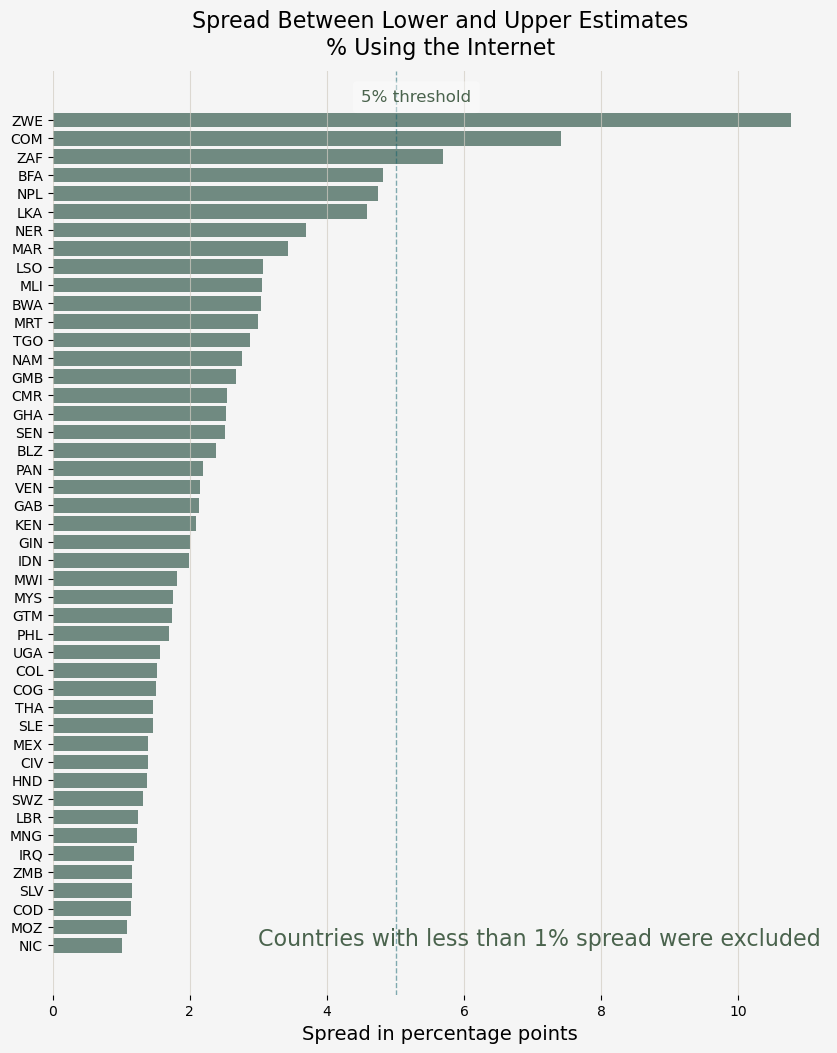

In [37]:
dashed_5p_annotation = "5% threshold"
expl_annotation = (
    "Countries with less than 1% spread were excluded"
)

plot_data = internet_data[internet_data['spread'] > 0.01]

utils.pretty_hbar(plot_data.index, plot_data['spread'] * 100,
                 vertical_lines = [5],
                 plot_title = "Spread Between Lower and Upper Estimates\n% Using the Internet",
                  x_axis_title="Spread in percentage points",
                 annotation = [
                {"bbox": {
                            "boxstyle": "round,pad=0.5,rounding_size=0.25",
                            "fc": "white",          # fill color
                            "ec": "none",
                            #"ec": "#a5c4b6",
                            #"lw": 1,
                            "alpha": 0.4
                    },
                    "text": dashed_5p_annotation,
                    "xy": (0,0),
                    "xytext": (4.5, 46),
                    "color": "#4a634d",
                    "fontsize": 12
                },
                {"bbox": None,
                    "text": expl_annotation,
                    "xy": (0,0),
                    "xytext": (3, 0),
                    "color": "#4a634d",
                    "fontsize": 16
                }
                ],
        save_file = pic_folder + 'internet_use_spreads.png'
)

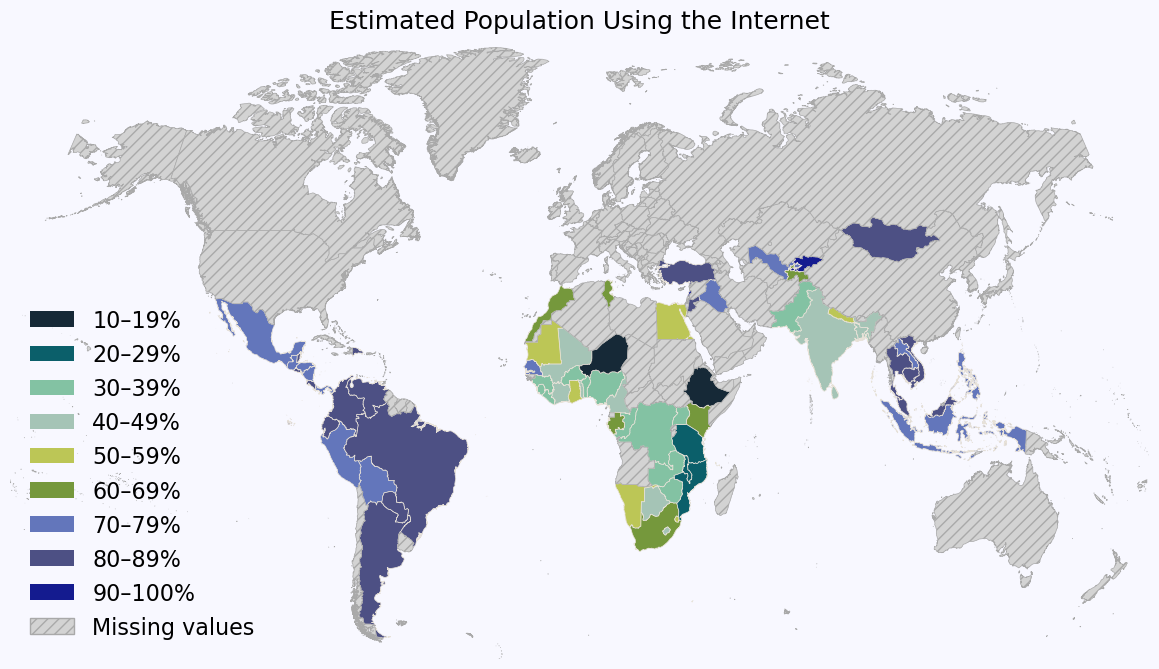

In [38]:
plot_data = internet_data.reset_index()
plot_data = plot_data[['country_id', 'zero_spread_der']].copy()
plot_data.dropna(inplace = True)
plot_data['zero_spread_der'] = plot_data['zero_spread_der'] * 100

plot_buckets_countries(10, 
                       plot_data, 
                       'zero_spread_der', 
                       palette,
                      title = "Estimated Population Using the Internet",
                      save_file = pic_folder + "internet_use.png")